# Voting Classifier 

## 0. Import Necessary Modules

### Import Torch 

In [1]:
import torch

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print("MPS device not found.")

tensor([1.], device='mps:0')


In [2]:
device = "mps" if torch.mps.is_available() else "cpu"
print(f"✅ Using device: {device}")

✅ Using device: mps


### Import Other Libraries 

In [3]:
# Data Analysis Libraries
import pandas as pd
import numpy as np
from IPython.display import HTML, display
from pprint import pprint

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 7)

# Machine Learning Libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from tqdm import tqdm  # progress bar

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")

Current pandas version: 2.0.3


## 1. Load LightGBM Model 

## 2. Pytorch MLP Model (Skorch)

### Load Neural Network 

In [4]:
from src.modeling.models import FraudNN

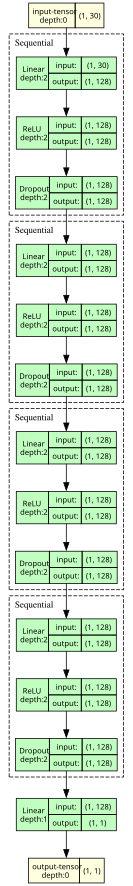

In [ ]:
import torch
from torchview import draw_graph
from src.modeling.models import FraudNN

# Load model
checkpoint = torch.load(
    "models/pytorch_mlp_fraud_model.pth", map_location="cpu", weights_only=False
)
model_state_dict = checkpoint["model_state_dict"]
best_hyperparams = checkpoint["hyperparameters"]

model = FraudNN(**best_hyperparams)
model.load_state_dict(model_state_dict)
model.eval()


model_graph = draw_graph(
    model,
    input_size=(1, 30),
    expand_nested=True,
    save_graph=False,
    filename="fraud_model",
)

# Display
display(model_graph.visual_graph)


In [11]:
best_hyperparams

{'input_features': 30,
 'hidden_units': 128,
 'num_layers': 3,
 'dropout_rate': 0.3,
 'learning_rate': 0.001,
 'output_features': 1,
 'threshold': 0.5}

### Wrap Pytorch Model (Skorch)

In [8]:
print('Importing Libraries... ',end='')
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from skorch import NeuralNetClassifier
from skorch.callbacks import EarlyStopping
from skorch.dataset import Dataset
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
print('Done')

Importing Libraries... Done


In [ ]:
# Wrap the model in Skorch NeuralNetClassifier
digit_classifier = NeuralNetClassifier(
    module = model,     # neural network model 
    max_epochs = 10,
    lr = best_hyperparams['learning_rate'],
    iterator_train__batch_size = ,
    iterator_train__shuffle = True,
    iterator_valid__batch_size = batch_size,
    iterator_valid__shuffle = False,
    criterion = nn.CrossEntropyLoss,
    optimizer = torch.optim.Adam,
    callbacks = [EarlyStopping(patience=patience)],
    device = device
)

NameError: name 'DigitClassifier' is not defined